# BOW With Basic Features

## Import Libraries

In [ ]:
import os 
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Path Configs

In [ ]:
# ── Add project root to path so app.config is importable ─────────────────────
PROJECT_ROOT = os.getcwd()
sys.path.append(PROJECT_ROOT)

# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT_PATH  = os.path.join("../data", "quora_question_pair.csv")


(404290, 6)

## Loading Dataset

In [ ]:
df = pd.read_csv(INPUT_PATH)
print(df.shape)
df.head()

In [3]:
new_df = df.sample(30000)

In [4]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 18583 to 350201
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            30000 non-null  int64 
 1   qid1          30000 non-null  int64 
 2   qid2          30000 non-null  int64 
 3   question1     30000 non-null  object
 4   question2     30000 non-null  object
 5   is_duplicate  30000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 1.6+ MB


In [5]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [6]:
new_df.duplicated().sum()

np.int64(0)

is_duplicate
0    18882
1    11118
Name: count, dtype: int64
is_duplicate
0    62.94
1    37.06
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

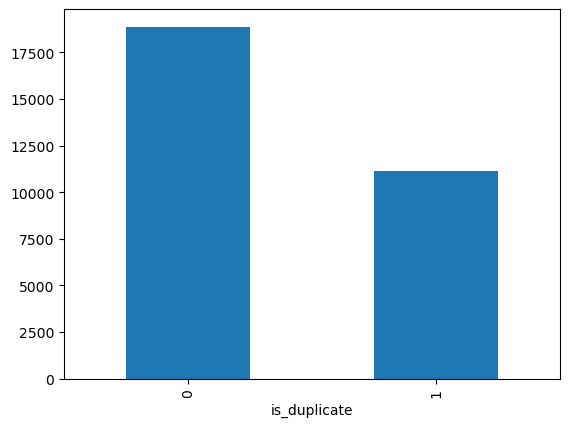

In [ ]:
print(round(new_df['is_duplicate'].value_counts()/len(new_df)*100,3))
new_df['is_duplicate'].value_counts().plot(kind='bar')

In [8]:
qid = pd.Series(new_df['qid1'].to_list() + new_df['qid2'].to_list())
print("Number of unique questions : ",np.unique(qid).shape[0])
x = qid.value_counts() > 1
print("Number of questions getting repeated : ", x[x].shape[0])

Number of unique questions :  55327
Number of questions getting repeated :  3442


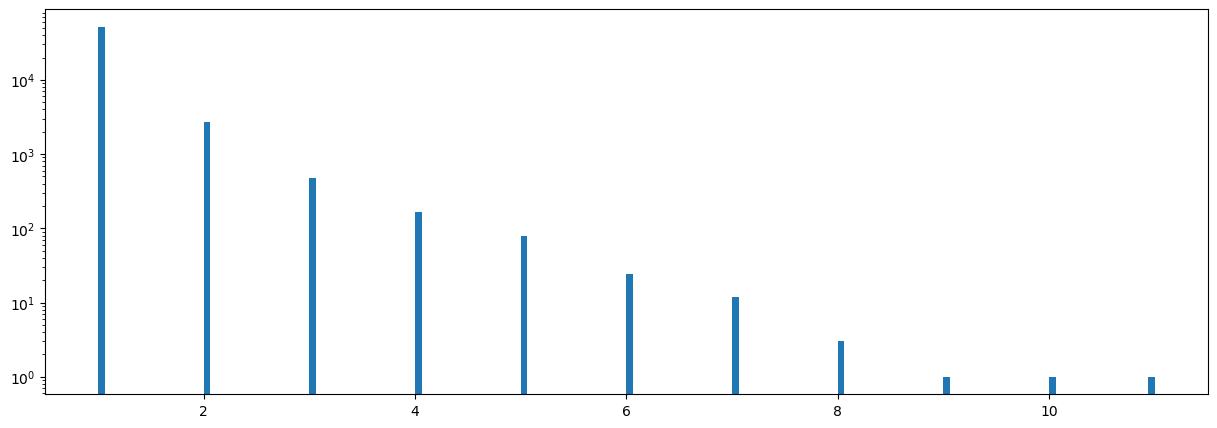

In [9]:
# Repeated questions histogram
plt.figure(figsize=(15,5))
plt.hist(qid.value_counts().values, bins=160)
plt.yscale('log')
plt.show()

## Custom/Basic Feature Engineering

### Length of question1 and question2

In [ ]:
new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
18583,18583,35197,35198,Which are some of notable startups run by PSG ...,PSG College of Technology: Who are some notabl...,0,71,99
291595,291595,61552,123395,Is Quora's engine biased against Donald Trump?,Why is Quora so much against Trump?,1,46,35
9753,9753,18941,18942,Are there any films about Bill Gates?,What are some common misconceptions about Bill...,0,37,53
83070,83070,140725,140726,What do we expect from life?,What should you expect from your life?,0,28,38
375451,375451,104218,140538,Who are the most interesting and famous populi...,Who are the most interesting and famous populi...,0,88,98


### Number of words in question1 and question2

In [ ]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda x: len(x.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda x: len(x.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
18583,18583,35197,35198,Which are some of notable startups run by PSG ...,PSG College of Technology: Who are some notabl...,0,71,99,12,16
291595,291595,61552,123395,Is Quora's engine biased against Donald Trump?,Why is Quora so much against Trump?,1,46,35,7,7
9753,9753,18941,18942,Are there any films about Bill Gates?,What are some common misconceptions about Bill...,0,37,53,7,8
83070,83070,140725,140726,What do we expect from life?,What should you expect from your life?,0,28,38,6,7
375451,375451,104218,140538,Who are the most interesting and famous populi...,Who are the most interesting and famous populi...,0,88,98,15,15


### Number of common words in question1 and question2

In [ ]:
def common_words(row):
    w1 = set(map(lambda word:word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word:word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [ ]:
new_df['num_word_common'] = new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
18583,18583,35197,35198,Which are some of notable startups run by PSG ...,PSG College of Technology: Who are some notabl...,0,71,99,12,16,5
291595,291595,61552,123395,Is Quora's engine biased against Donald Trump?,Why is Quora so much against Trump?,1,46,35,7,7,3
9753,9753,18941,18942,Are there any films about Bill Gates?,What are some common misconceptions about Bill...,0,37,53,7,8,4
83070,83070,140725,140726,What do we expect from life?,What should you expect from your life?,0,28,38,6,7,4
375451,375451,104218,140538,Who are the most interesting and famous populi...,Who are the most interesting and famous populi...,0,88,98,15,15,14


### Total number of unique words in both questions combined

In [ ]:
def total_words(row):
    w1 = set(map(lambda word:word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word:word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [ ]:
new_df['word_total'] = new_df.apply(total_words,axis=1)
new_df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
18583,18583,35197,35198,Which are some of notable startups run by PSG ...,PSG College of Technology: Who are some notabl...,0,71,99,12,16,5,28
291595,291595,61552,123395,Is Quora's engine biased against Donald Trump?,Why is Quora so much against Trump?,1,46,35,7,7,3,14
9753,9753,18941,18942,Are there any films about Bill Gates?,What are some common misconceptions about Bill...,0,37,53,7,8,4,15


In [16]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
new_df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
18583,18583,35197,35198,Which are some of notable startups run by PSG ...,PSG College of Technology: Who are some notabl...,0,71,99,12,16,5,28,0.18
291595,291595,61552,123395,Is Quora's engine biased against Donald Trump?,Why is Quora so much against Trump?,1,46,35,7,7,3,14,0.21
9753,9753,18941,18942,Are there any films about Bill Gates?,What are some common misconceptions about Bill...,0,37,53,7,8,4,15,0.27


## Creating df to train model

In [24]:
ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
18583,Which are some of notable startups run by PSG ...,PSG College of Technology: Who are some notabl...
291595,Is Quora's engine biased against Donald Trump?,Why is Quora so much against Trump?
9753,Are there any films about Bill Gates?,What are some common misconceptions about Bill...
83070,What do we expect from life?,What should you expect from your life?
375451,Who are the most interesting and famous populi...,Who are the most interesting and famous populi...


In [25]:
final_df = new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
18583,0,71,99,12,16,5,28,0.18
291595,1,46,35,7,7,3,14,0.21
9753,0,37,53,7,8,4,15,0.27
83070,0,28,38,6,7,4,13,0.31
375451,0,88,98,15,15,14,30,0.47


### Applying BOW

In [ ]:
questions = list(ques_df['question1']) + list(ques_df['question2'])
cv = CountVectorizer(max_features = 3000)

In [27]:
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [28]:
temp_df1 = pd.DataFrame(q1_arr, index = ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index = ques_df.index)
temp_df = pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [29]:
final_df = pd.concat([final_df, temp_df],axis=1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
18583,0,71,99,12,16,5,28,0.18,0,0,...,0,0,0,0,0,0,0,0,0,0
291595,1,46,35,7,7,3,14,0.21,0,0,...,0,0,0,0,0,0,0,0,0,0
9753,0,37,53,7,8,4,15,0.27,0,0,...,0,0,0,0,0,0,0,0,0,0
83070,0,28,38,6,7,4,13,0.31,0,0,...,0,0,1,0,0,1,0,0,0,0
375451,0,88,98,15,15,14,30,0.47,0,0,...,0,0,0,0,0,0,0,0,0,0


## Dividing Feature and Target Variable

In [ ]:
x = final_df.iloc[:,1:].values
y = final_df.iloc[:,0].values

## Splitting Training and Testing Set

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=1)

## Training Models

In [ ]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
accuracy_score(y_test, y_pred)

0.769

In [ ]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)
accuracy_score(y_test, y_pred)

0.7716666666666666